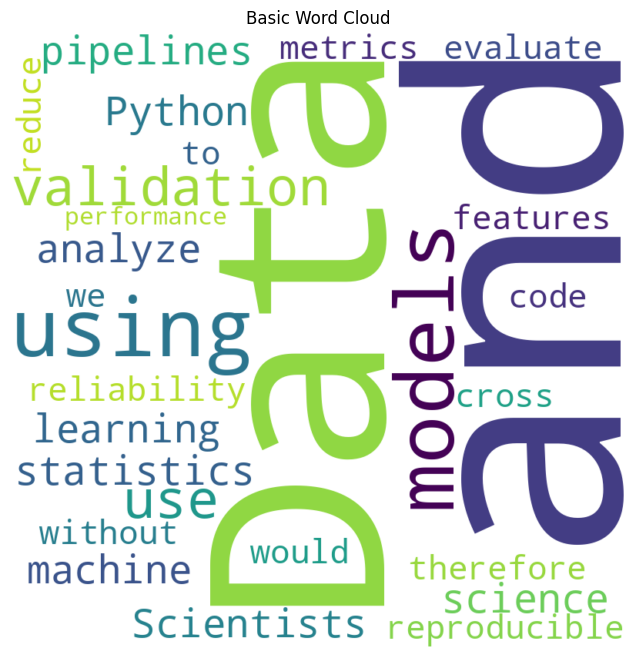

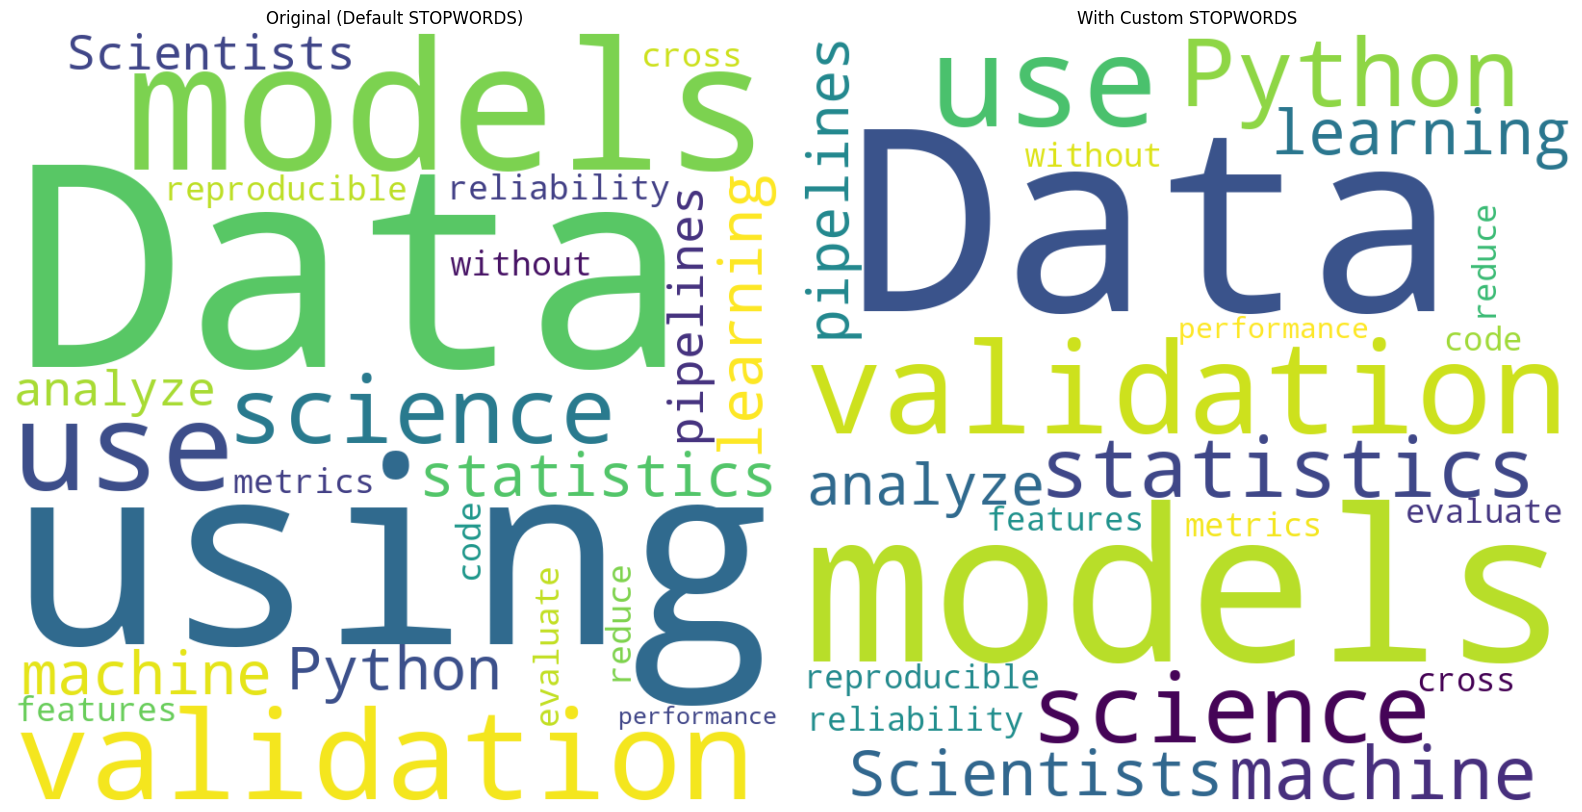

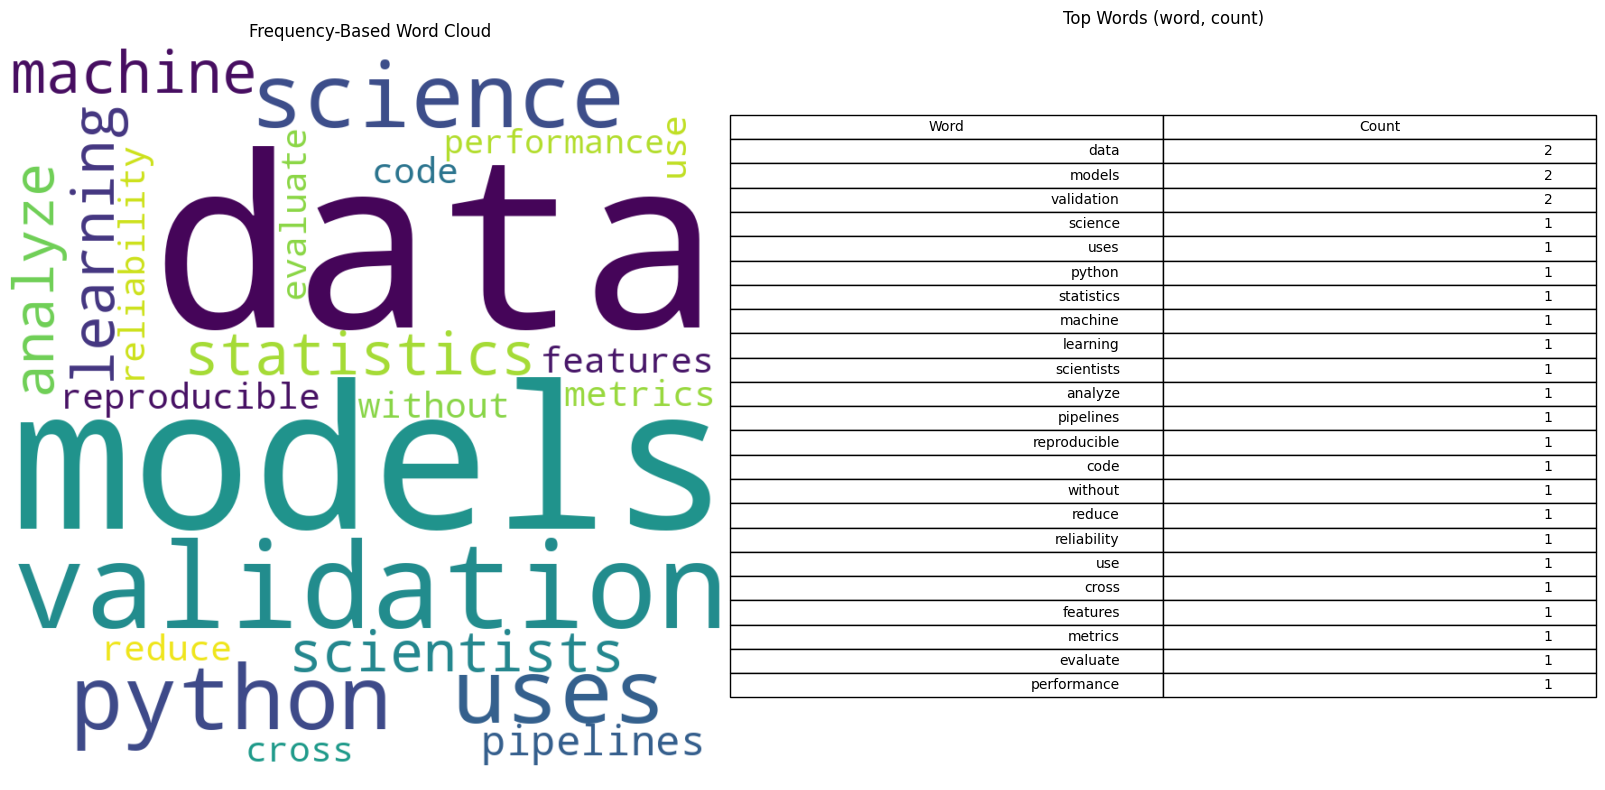

In [1]:
# Exercise 1: Word Cloud Generation
# ---------------------------------
# Requires: wordcloud, matplotlib

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

# ---------- Helpers ----------

def _plot_wordcloud(wc, title="Word Cloud", figsize=(8, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# ---------- Basic Word Cloud Implementation ----------

def build_wordcloud(
    text: str,
    width: int = 800,
    height: int = 800,
    background_color: str = "white",
    min_font_size: int = 10,
    stopwords: set | None = None,
):
    """
    Create a simple word cloud from raw text.
    """
    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        min_font_size=min_font_size,
        stopwords=stopwords or set()
    ).generate(text)
    return wc

# =====================================================================
# Question 1: Enhance with custom stop words & side-by-side comparison
# =====================================================================

def compare_wordclouds(
    text: str,
    custom_stopwords: set | None = None,
    width: int = 800,
    height: int = 800,
):
    """
    Generate two word clouds:
      1) baseline using default STOPWORDS
      2) enhanced using default STOPWORDS + custom_stopwords
    Display them side by side for comparison.
    """
    base_stop = set(STOPWORDS)
    enhanced_stop = set(STOPWORDS)
    if custom_stopwords:
        enhanced_stop |= set(custom_stopwords)

    wc_base = build_wordcloud(text, width=width, height=height, stopwords=base_stop)
    wc_enh = build_wordcloud(text, width=width, height=height, stopwords=enhanced_stop)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(wc_base, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title("Original (Default STOPWORDS)")

    axes[1].imshow(wc_enh, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title("With Custom STOPWORDS")

    plt.tight_layout()
    plt.show()

# =====================================================================
# Question 2: Frequency-based word cloud + frequency list
# =====================================================================

_WORD_RE = re.compile(r"[A-Za-z']+")

def top_n_frequencies(
    text: str,
    n: int = 50,
    extra_stopwords: set | None = None,
    min_len: int = 3,
):
    """
    Tokenize text, remove stopwords/short words, and return top-N (word, count).
    """
    tokens = [t.lower() for t in _WORD_RE.findall(text)]
    stop = set(STOPWORDS)
    if extra_stopwords:
        stop |= set(extra_stopwords)

    filtered = [t for t in tokens if len(t) >= min_len and t not in stop]
    counts = Counter(filtered).most_common(n)
    return counts

def frequency_wordcloud_and_list(
    text: str,
    n: int = 50,
    extra_stopwords: set | None = None,
    min_len: int = 3,
    width: int = 800,
    height: int = 800,
):
    """
    Build a word cloud from top-N frequencies and show
    (left) the cloud and (right) a table of word -> count.
    """
    freqs = top_n_frequencies(text, n=n, extra_stopwords=extra_stopwords, min_len=min_len)

    # WordCloud from frequency dict
    wc = WordCloud(
        width=width,
        height=height,
        background_color="white"
    ).generate_from_frequencies(dict(freqs))

    # Plot cloud + frequency table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # Word cloud
    ax1.imshow(wc, interpolation="bilinear")
    ax1.axis("off")
    ax1.set_title("Frequency-Based Word Cloud")

    # Frequency list as a table
    ax2.axis("off")
    ax2.set_title("Top Words (word, count)")
    table_data = [(w, c) for w, c in freqs]
    table = ax2.table(cellText=table_data, colLabels=["Word", "Count"], loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    plt.tight_layout()
    plt.show()

# ---------- Example usage ----------

if __name__ == "__main__":
    sample_text = (
        "Data science uses Python, statistics, and machine learning. "
        "Scientists analyze data using models, pipelines, and reproducible code. "
        "Using models without validation would reduce reliability; therefore, "
        "we use cross-validation, features, and metrics to evaluate performance."
    )

    # Basic word cloud
    wc = build_wordcloud(sample_text)
    _plot_wordcloud(wc, "Basic Word Cloud")

    # Q1: Custom stop words comparison
    custom = {"said", "using", "would"}  # add any domain-specific fillers here
    compare_wordclouds(sample_text, custom_stopwords=custom)

    # Q2: Frequency-based cloud + list
    frequency_wordcloud_and_list(sample_text, n=30, extra_stopwords=custom, min_len=3)


Most Positive Tweet:
  compound=+0.998  pos=0.77  neg=0.00
  WOWWWW, Thanks a lot team :) ❤💙💚💕❤💙💚💕  ❤💙💚💕❤💙💚💕 via @ManoharRpm

Most Negative Tweet:
  compound=-0.987  pos=0.00  neg=0.60
  @jjjaneell hay idk baby :( 😭😭😭😭😭😭😭😭😭😭


=== Top Positive Tweets ===
 1. compound=+0.998  pos=0.77  neg=0.00
    WOWWWW, Thanks a lot team :) ❤💙💚💕❤💙💚💕  ❤💙💚💕❤💙💚💕 via @ManoharRpm

 2. compound=+0.998  pos=0.78  neg=0.00
    @MaxivisionEye WOWWWW, Thanks a lot team :) ❤💙💚💕❤💙💚💕  ❤💙💚💕❤💙💚💕

 3. compound=+0.994  pos=0.49  neg=0.04
    @Varun_dvn Okeyyyyyy VDDDD :)));))))  So excited can't wait ... ! ! Love selfeeee pics on insta :) ♥♥ special coco .. 🙆🙌😛😄😄😁😂😂🐒😁😝❤ #dishoom

 4. compound=+0.989  pos=0.46  neg=0.09
    @JayMcGuiness happy birthday again! And please come back to singapore :-( 😿💓💓💕😚😚😚😚😚❤️❤️❤️❤️❤️ http://t.co/5LIiqJqpBt

 5. compound=+0.987  pos=0.75  neg=0.00
    There :) is :) a :) pimple :) on :) my :) forehead :) the :) size :) of :) a :) volcano :)

=== Top Negative Tweets ===
 1. compound=-0.9

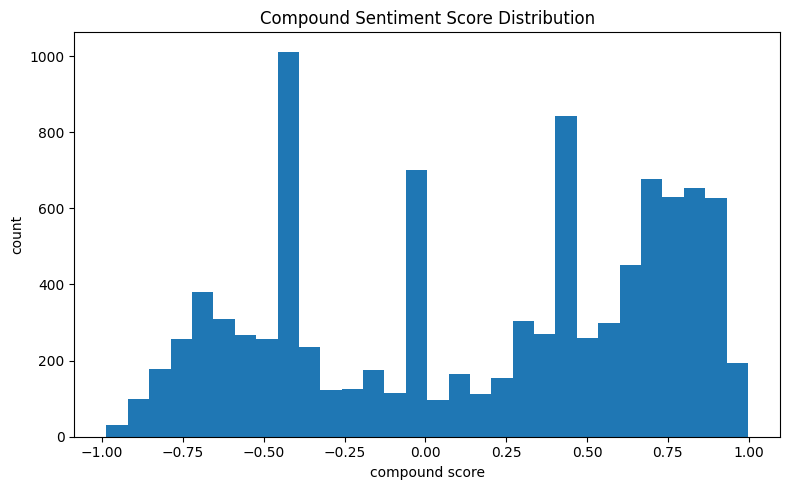

In [3]:
# Exercise 2: Social Media Sentiment Analysis — Q3
# ------------------------------------------------
# Requires: nltk, vaderSentiment, matplotlib

import nltk
from nltk.corpus import twitter_samples
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# ---- Setup helpers (downloads & analyzer with try/except) ----
def _ensure_nltk_data():
    try:
        twitter_samples.fileids()
    except LookupError:
        nltk.download("twitter_samples")

def _make_analyzer():
    try:
        return SentimentIntensityAnalyzer()
    except Exception as e:
        raise RuntimeError(
            "Failed to initialize VADER SentimentIntensityAnalyzer."
        ) from e

# ---- Core analysis helpers ----
def analyze_tweets(analyzer, tweets):
    """
    Return a list of dicts:
    { 'text': str, 'compound': float, 'pos': float, 'neg': float, 'neu': float }
    """
    results = []
    for t in tweets:
        s = analyzer.polarity_scores(t)
        results.append({
            "text": t,
            "compound": s["compound"],
            "pos": s["pos"],
            "neg": s["neg"],
            "neu": s["neu"],
        })
    return results

def sort_by_compound(results, reverse=True):
    """Sort tweet results by 'compound' score (desc by default)."""
    return sorted(results, key=lambda r: r["compound"], reverse=reverse)

def most_extreme(results):
    """Return (most_positive, most_negative) tweets by compound score."""
    if not results:
        return None, None
    sorted_res = sort_by_compound(results, reverse=True)
    most_pos = sorted_res[0]
    most_neg = sorted_res[-1]
    return most_pos, most_neg

def print_formatted(results, top_n=5):
    """Pretty print top-N positive and negative tweets with scores."""
    pos_sorted = sort_by_compound(results, True)[:top_n]
    neg_sorted = sort_by_compound(results, False)[:top_n]

    print("\n=== Top Positive Tweets ===")
    for i, r in enumerate(pos_sorted, 1):
        print(f"{i:>2}. compound={r['compound']:+.3f}  pos={r['pos']:.2f}  neg={r['neg']:.2f}")
        print(f"    {r['text']}\n")

    print("=== Top Negative Tweets ===")
    for i, r in enumerate(neg_sorted, 1):
        print(f"{i:>2}. compound={r['compound']:+.3f}  pos={r['pos']:.2f}  neg={r['neg']:.2f}")
        print(f"    {r['text']}\n")

def plot_compound_hist(results, bins=30, title="Compound Sentiment Score Distribution"):
    """Histogram of compound sentiment scores."""
    scores = [r["compound"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.hist(scores, bins=bins)
    plt.title(title)
    plt.xlabel("compound score")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ---- Demo / Usage ----
if __name__ == "__main__":
    _ensure_nltk_data()
    analyzer = _make_analyzer()

    # Load sample tweets (both positive and negative)
    pos = twitter_samples.strings("positive_tweets.json")
    neg = twitter_samples.strings("negative_tweets.json")
    tweets = pos + neg

    # Analyze
    results = analyze_tweets(analyzer, tweets)

    # Extremes
    most_pos, most_neg = most_extreme(results)
    print("Most Positive Tweet:")
    print(f"  compound={most_pos['compound']:+.3f}  pos={most_pos['pos']:.2f}  neg={most_pos['neg']:.2f}")
    print(f"  {most_pos['text']}\n")

    print("Most Negative Tweet:")
    print(f"  compound={most_neg['compound']:+.3f}  pos={most_neg['pos']:.2f}  neg={most_neg['neg']:.2f}")
    print(f"  {most_neg['text']}\n")

    # Sorted views & formatted output
    print_formatted(results, top_n=5)

    # Histogram of compound scores
    plot_compound_hist(results, bins=30)
